# British Airways - Task 2: Model Training & Evaluation
Trains **Random Forest** and **XGBoost** on the processed data from `eda_and_prep.ipynb`.

For each model, the following are reported:
- **Training metrics** - to detect overfitting
- **5-fold stratified CV** - unbiased estimate of generalisation
- **Held-out test metrics** - final evaluation on unseen data
- **Confusion matrix, ROC curve, Precision-Recall curve, Feature importances**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
SEED = 42

---
## 1. Load Processed Data

In [2]:
train = pd.read_csv('processed_train.csv')
test  = pd.read_csv('processed_test.csv')

TARGET = 'booking_complete'
FEATURES = [c for c in train.columns if c != TARGET]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

# Class imbalance ratio for XGBoost
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f'Train: {X_train.shape}   Test: {X_test.shape}')
print(f'Train positive rate: {y_train.mean():.3f}   Test positive rate: {y_test.mean():.3f}')
print(f'scale_pos_weight (for XGBoost): {scale_pos_weight:.2f}')
print(f'\nFeatures ({len(FEATURES)}):', FEATURES)

Train: (40000, 19)   Test: (10000, 19)
Train positive rate: 0.150   Test positive rate: 0.150
scale_pos_weight (for XGBoost): 5.69

Features (19): ['num_passengers', 'flight_hour', 'flight_day', 'wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals', 'flight_duration', 'total_ancillaries', 'is_weekend', 'is_solo', 'log_purchase_lead', 'log_length_of_stay', 'sales_channel_Mobile', 'trip_type_OneWay', 'trip_type_RoundTrip', 'route_freq', 'booking_origin_freq', 'route_origin_freq', 'route_dest_freq']


---
## 2. Helper Functions

In [3]:
def get_metrics(y_true, y_pred, y_proba, label=''):
    """Return a dict of classification metrics."""
    return {
        'Split':     label,
        'Accuracy':  round(accuracy_score(y_true, y_pred),  4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred),    4),
        'F1':        round(f1_score(y_true, y_pred),        4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_proba),  4),
    }


def run_cv(model, X, y, n_splits=5):
    """Stratified k-fold CV — returns mean ± std for each metric."""
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    results = cross_validate(model, X, y, cv=cv, scoring=scoring,
                             return_train_score=True, n_jobs=-1)
    summary = {}
    for metric in scoring:
        val_scores = results[f'test_{metric}']
        summary[metric] = f'{val_scores.mean():.4f} ± {val_scores.std():.4f}'
    return summary, results


def plot_confusion(y_true, y_pred, model_name, ax):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Complete', 'Complete'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name} — Confusion Matrix', fontweight='bold')


def plot_feature_importance(model, feature_names, model_name, ax, top_n=15):
    imp = pd.Series(model.feature_importances_, index=feature_names)
    imp = imp.nlargest(top_n).sort_values()
    colors = ['#E87D5B' if i >= len(imp) - 3 else '#5B8DB8' for i in range(len(imp))]
    imp.plot.barh(ax=ax, color=colors, edgecolor='white')
    ax.set_title(f'{model_name} — Top {top_n} Feature Importances', fontweight='bold')
    ax.set_xlabel('Importance (Gini)' if 'Forest' in model_name else 'Importance (Gain)')
    for bar, val in zip(ax.patches, imp.values):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

---
## 3. Random Forest
### Cross-Validation (5-fold Stratified)

In [4]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

print('Running 5-fold stratified CV for Random Forest...')
rf_cv_summary, rf_cv_results = run_cv(rf, X_train, y_train)

print('\nRandom Forest — Cross-Validation Results (mean ± std):')
print('-' * 50)
for metric, val in rf_cv_summary.items():
    print(f'  {metric:<12}: {val}')

Running 5-fold stratified CV for Random Forest...

Random Forest — Cross-Validation Results (mean ± std):
--------------------------------------------------
  accuracy    : 0.8147 ± 0.0039
  precision   : 0.3919 ± 0.0100
  recall      : 0.4326 ± 0.0089
  f1          : 0.4112 ± 0.0079
  roc_auc     : 0.7827 ± 0.0039


### Train on Full Training Set + Evaluate on Train & Test

In [5]:
rf.fit(X_train, y_train)

# Training metrics
rf_train_pred  = rf.predict(X_train)
rf_train_proba = rf.predict_proba(X_train)[:, 1]
rf_train_metrics = get_metrics(y_train, rf_train_pred, rf_train_proba, 'Train')

# Test metrics
rf_test_pred  = rf.predict(X_test)
rf_test_proba = rf.predict_proba(X_test)[:, 1]
rf_test_metrics = get_metrics(y_test, rf_test_pred, rf_test_proba, 'Test')

rf_metrics_df = pd.DataFrame([rf_train_metrics, rf_test_metrics]).set_index('Split')
print('Random Forest — Train vs Test Metrics')
print(rf_metrics_df.to_string())
print('\n(Large gap between Train and Test = overfitting)')

print('\nFull Classification Report (Test):')
print(classification_report(y_test, rf_test_pred, target_names=['Not Complete', 'Complete']))

Random Forest — Train vs Test Metrics
       Accuracy  Precision  Recall      F1  ROC-AUC
Split                                              
Train    0.9190     0.6693  0.9062  0.7699   0.9723
Test     0.8147     0.3981  0.4659  0.4293   0.7913

(Large gap between Train and Test = overfitting)

Full Classification Report (Test):
              precision    recall  f1-score   support

Not Complete       0.90      0.88      0.89      8504
    Complete       0.40      0.47      0.43      1496

    accuracy                           0.81     10000
   macro avg       0.65      0.67      0.66     10000
weighted avg       0.83      0.81      0.82     10000



---
## 4. XGBoost
### Cross-Validation (5-fold Stratified)

In [6]:
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=SEED,
    n_jobs=-1
)

print('Running 5-fold stratified CV for XGBoost...')
xgb_cv_summary, xgb_cv_results = run_cv(xgb, X_train, y_train)

print('\nXGBoost — Cross-Validation Results (mean ± std):')
print('-' * 50)
for metric, val in xgb_cv_summary.items():
    print(f'  {metric:<12}: {val}')

Running 5-fold stratified CV for XGBoost...

XGBoost — Cross-Validation Results (mean ± std):
--------------------------------------------------
  accuracy    : 0.7511 ± 0.0055
  precision   : 0.3313 ± 0.0070
  recall      : 0.6520 ± 0.0122
  f1          : 0.4393 ± 0.0079
  roc_auc     : 0.7847 ± 0.0056


### Train on Full Training Set + Evaluate on Train & Test

In [7]:
xgb.fit(X_train, y_train)

# Training metrics
xgb_train_pred  = xgb.predict(X_train)
xgb_train_proba = xgb.predict_proba(X_train)[:, 1]
xgb_train_metrics = get_metrics(y_train, xgb_train_pred, xgb_train_proba, 'Train')

# Test metrics
xgb_test_pred  = xgb.predict(X_test)
xgb_test_proba = xgb.predict_proba(X_test)[:, 1]
xgb_test_metrics = get_metrics(y_test, xgb_test_pred, xgb_test_proba, 'Test')

xgb_metrics_df = pd.DataFrame([xgb_train_metrics, xgb_test_metrics]).set_index('Split')
print('XGBoost — Train vs Test Metrics')
print(xgb_metrics_df.to_string())
print('\n(Large gap between Train and Test = overfitting)')

print('\nFull Classification Report (Test):')
print(classification_report(y_test, xgb_test_pred, target_names=['Not Complete', 'Complete']))

XGBoost — Train vs Test Metrics
       Accuracy  Precision  Recall      F1  ROC-AUC
Split                                              
Train    0.8060     0.4285  0.8907  0.5786   0.9173
Test     0.7436     0.3265  0.6718  0.4394   0.7947

(Large gap between Train and Test = overfitting)

Full Classification Report (Test):
              precision    recall  f1-score   support

Not Complete       0.93      0.76      0.83      8504
    Complete       0.33      0.67      0.44      1496

    accuracy                           0.74     10000
   macro avg       0.63      0.71      0.64     10000
weighted avg       0.84      0.74      0.77     10000



---
## 5. Model Comparison - Side-by-Side

In [8]:
# CV summary comparison
cv_compare = pd.DataFrame({
    'Random Forest (CV)': rf_cv_summary,
    'XGBoost (CV)':       xgb_cv_summary
})
print('5-Fold CV Comparison (mean ± std on validation folds):')
print(cv_compare.to_string())

print()

# Test set comparison
test_compare = pd.DataFrame({
    'Random Forest': rf_test_metrics,
    'XGBoost':       xgb_test_metrics
}).T.drop(columns='Split')
print('Test Set Comparison:')
print(test_compare.to_string())

5-Fold CV Comparison (mean ± std on validation folds):
          Random Forest (CV)     XGBoost (CV)
accuracy     0.8147 ± 0.0039  0.7511 ± 0.0055
precision    0.3919 ± 0.0100  0.3313 ± 0.0070
recall       0.4326 ± 0.0089  0.6520 ± 0.0122
f1           0.4112 ± 0.0079  0.4393 ± 0.0079
roc_auc      0.7827 ± 0.0039  0.7847 ± 0.0056

Test Set Comparison:
              Accuracy Precision  Recall      F1 ROC-AUC
Random Forest   0.8147    0.3981  0.4659  0.4293  0.7913
XGBoost         0.7436    0.3265  0.6718  0.4394  0.7947


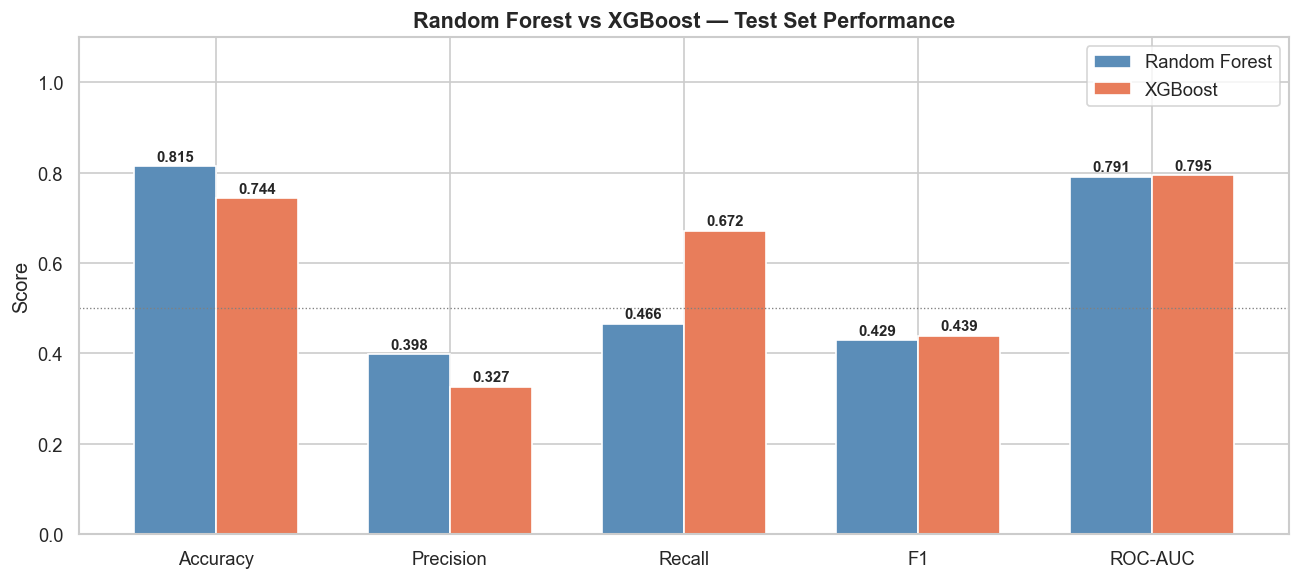

In [9]:
# Visual comparison bar chart
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

rf_vals  = [rf_test_metrics[m]  for m in metrics_to_plot]
xgb_vals = [xgb_test_metrics[m] for m in metrics_to_plot]

x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars_rf  = ax.bar(x - width/2, rf_vals,  width, label='Random Forest', color='#5B8DB8', edgecolor='white')
bars_xgb = ax.bar(x + width/2, xgb_vals, width, label='XGBoost',       color='#E87D5B', edgecolor='white')

for bars in [bars_rf, bars_xgb]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Random Forest vs XGBoost — Test Set Performance', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(0.5, color='grey', linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.show()

---
## 6. Confusion Matrices

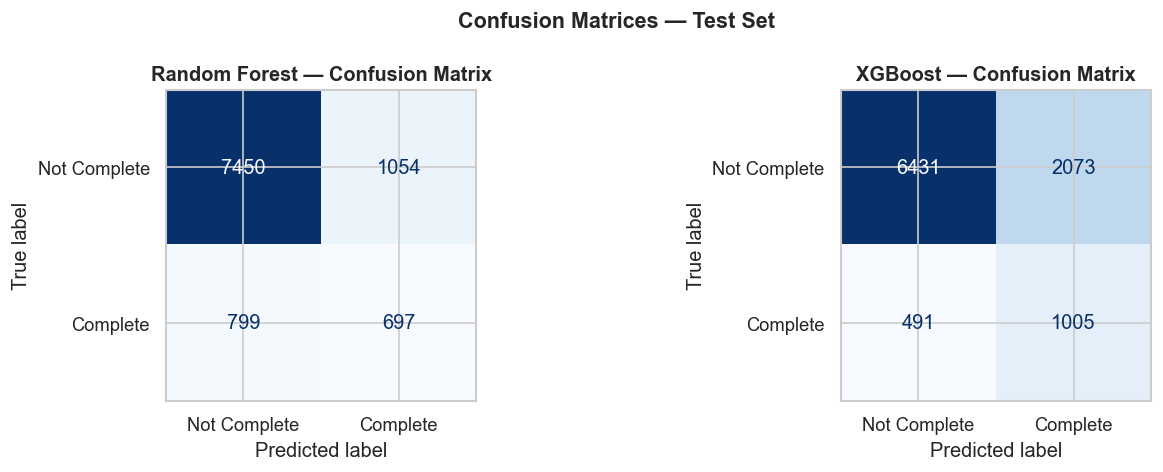

Confusion matrix layout:
  TN  FP    (TN=correctly predicted no-booking, FP=predicted booking but did not)
  FN  TP    (FN=missed actual booking, TP=correctly predicted booking)

For BA, missing a true booking (FN) is more costly than a false alarm (FP).
→ Higher Recall on the positive class is the business priority.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_confusion(y_test, rf_test_pred,  'Random Forest', axes[0])
plot_confusion(y_test, xgb_test_pred, 'XGBoost',       axes[1])
plt.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Explain the quadrants
print('Confusion matrix layout:')
print('  TN  FP    (TN=correctly predicted no-booking, FP=predicted booking but did not)')
print('  FN  TP    (FN=missed actual booking, TP=correctly predicted booking)')
print()
print('For BA, missing a true booking (FN) is more costly than a false alarm (FP).')
print('→ Higher Recall on the positive class is the business priority.')

---
## 7. ROC Curves

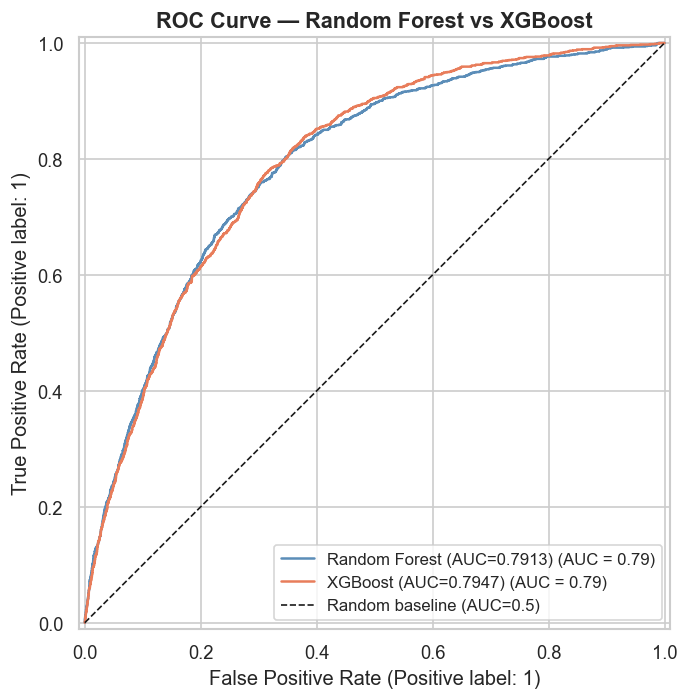

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test, rf_test_proba,
    name=f'Random Forest (AUC={roc_auc_score(y_test, rf_test_proba):.4f})',
    color='#5B8DB8', ax=ax
)
RocCurveDisplay.from_predictions(
    y_test, xgb_test_proba,
    name=f'XGBoost (AUC={roc_auc_score(y_test, xgb_test_proba):.4f})',
    color='#E87D5B', ax=ax
)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline (AUC=0.5)')
ax.set_title('ROC Curve — Random Forest vs XGBoost', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

---
## 8. Precision-Recall Curves
More informative than ROC when the positive class is rare (~15%). A model that scores high here is genuinely identifying bookers, not just benefiting from the majority class.

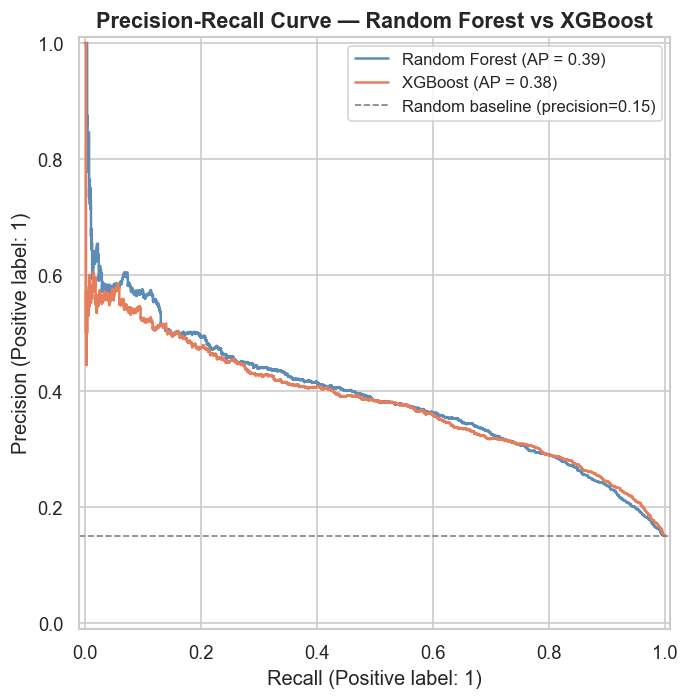

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(
    y_test, rf_test_proba,
    name='Random Forest',
    color='#5B8DB8', ax=ax
)
PrecisionRecallDisplay.from_predictions(
    y_test, xgb_test_proba,
    name='XGBoost',
    color='#E87D5B', ax=ax
)

# Baseline = random = positive class prevalence
baseline = y_test.mean()
ax.axhline(baseline, color='grey', linestyle='--', linewidth=1,
           label=f'Random baseline (precision={baseline:.2f})')
ax.set_title('Precision-Recall Curve — Random Forest vs XGBoost', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## 9. Cross-Validation Fold Detail
Shows AUC score per fold - consistent scores across folds = stable model.

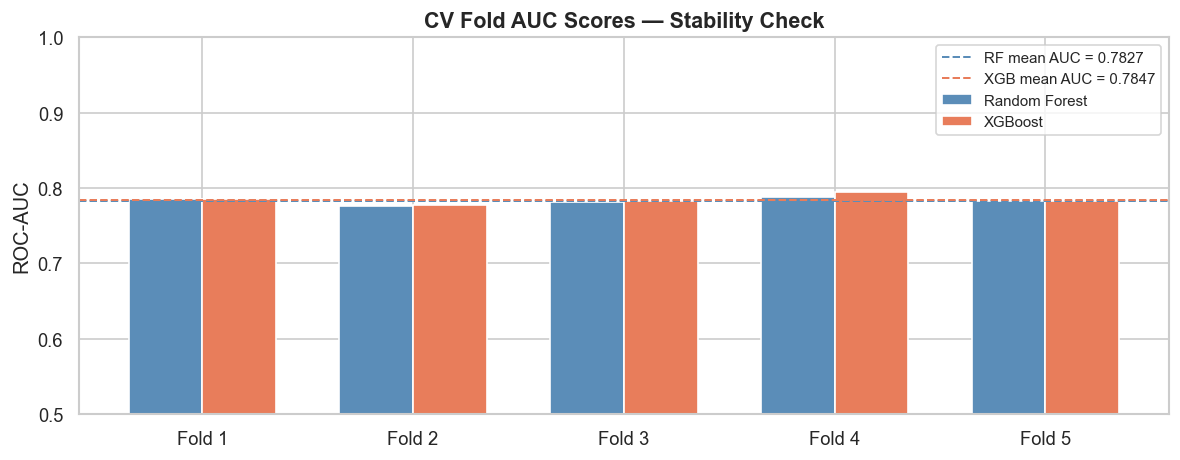

RF  AUC per fold: [0.7851 0.7762 0.7819 0.788  0.7822]  std=0.0039
XGB AUC per fold: [0.7856 0.7776 0.7829 0.7947 0.7829]  std=0.0056

Low std = model generalises consistently across different subsets of the data.


In [13]:
rf_fold_aucs  = rf_cv_results['test_roc_auc']
xgb_fold_aucs = xgb_cv_results['test_roc_auc']
folds = [f'Fold {i+1}' for i in range(5)]

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(5)
width = 0.35

ax.bar(x - width/2, rf_fold_aucs,  width, label='Random Forest', color='#5B8DB8', edgecolor='white')
ax.bar(x + width/2, xgb_fold_aucs, width, label='XGBoost',       color='#E87D5B', edgecolor='white')
ax.axhline(rf_fold_aucs.mean(),  color='#5B8DB8', linestyle='--', linewidth=1.2,
           label=f'RF mean AUC = {rf_fold_aucs.mean():.4f}')
ax.axhline(xgb_fold_aucs.mean(), color='#E87D5B', linestyle='--', linewidth=1.2,
           label=f'XGB mean AUC = {xgb_fold_aucs.mean():.4f}')

ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.5, 1.0)
ax.set_title('CV Fold AUC Scores — Stability Check', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'RF  AUC per fold: {np.round(rf_fold_aucs, 4)}  std={rf_fold_aucs.std():.4f}')
print(f'XGB AUC per fold: {np.round(xgb_fold_aucs, 4)}  std={xgb_fold_aucs.std():.4f}')
print('\nLow std = model generalises consistently across different subsets of the data.')

---
## 10. Feature Importances

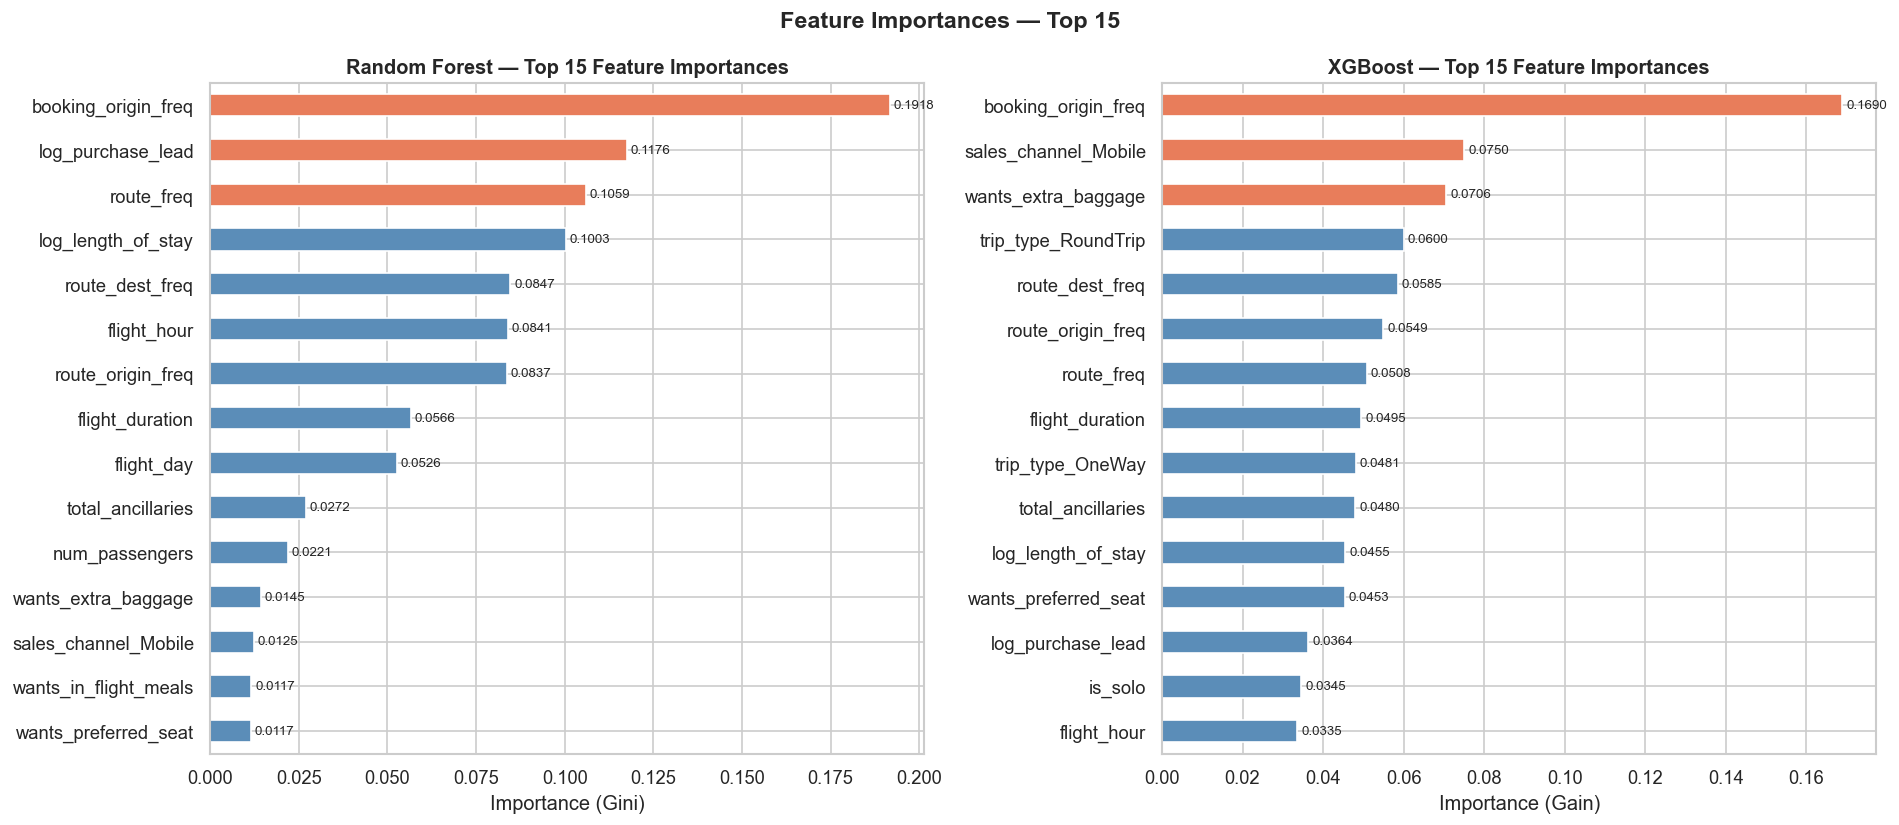

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
plot_feature_importance(rf,  FEATURES, 'Random Forest', axes[0], top_n=15)
plot_feature_importance(xgb, FEATURES, 'XGBoost',       axes[1], top_n=15)
plt.suptitle('Feature Importances — Top 15', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Full feature importance table — both models side by side
fi_df = pd.DataFrame({
    'Feature':       FEATURES,
    'RF_Importance': rf.feature_importances_,
    'XGB_Importance': xgb.feature_importances_
})
fi_df['RF_Rank']  = fi_df['RF_Importance'].rank(ascending=False).astype(int)
fi_df['XGB_Rank'] = fi_df['XGB_Importance'].rank(ascending=False).astype(int)
fi_df = fi_df.sort_values('RF_Importance', ascending=False).reset_index(drop=True)
fi_df[['Feature','RF_Importance','RF_Rank','XGB_Importance','XGB_Rank']] = \
    fi_df[['Feature','RF_Importance','RF_Rank','XGB_Importance','XGB_Rank']].round({'RF_Importance':5,'XGB_Importance':5})

print('Feature Importance Ranking — Random Forest vs XGBoost')
print(fi_df[['Feature','RF_Importance','RF_Rank','XGB_Importance','XGB_Rank']].to_string(index=False))

Feature Importance Ranking — Random Forest vs XGBoost
              Feature  RF_Importance  RF_Rank  XGB_Importance  XGB_Rank
  booking_origin_freq        0.19184        1         0.16898         1
    log_purchase_lead        0.11763        2         0.03636        13
           route_freq        0.10592        3         0.05084         7
   log_length_of_stay        0.10031        4         0.04553        11
      route_dest_freq        0.08473        5         0.05852         5
          flight_hour        0.08414        6         0.03353        15
    route_origin_freq        0.08371        7         0.05492         6
      flight_duration        0.05662        8         0.04948         8
           flight_day        0.05261        9         0.03146        17
    total_ancillaries        0.02719       10         0.04801        10
       num_passengers        0.02210       11         0.03195        16
  wants_extra_baggage        0.01447       12         0.07064         3
 sales_cha

---
## 11. Overfitting Diagnosis
Compare Train vs CV validation vs Test metrics in one table.

In [16]:
def extract_cv_mean(results, metric):
    return round(results[f'test_{metric}'].mean(), 4)

overfit_data = [
    # Random Forest
    {'Model': 'Random Forest', 'Split': 'Train',
     'AUC': rf_train_metrics['ROC-AUC'], 'F1': rf_train_metrics['F1'],
     'Recall': rf_train_metrics['Recall']},
    {'Model': 'Random Forest', 'Split': 'CV Val (mean)',
     'AUC': extract_cv_mean(rf_cv_results, 'roc_auc'),
     'F1':  extract_cv_mean(rf_cv_results, 'f1'),
     'Recall': extract_cv_mean(rf_cv_results, 'recall')},
    {'Model': 'Random Forest', 'Split': 'Test',
     'AUC': rf_test_metrics['ROC-AUC'], 'F1': rf_test_metrics['F1'],
     'Recall': rf_test_metrics['Recall']},
    # XGBoost
    {'Model': 'XGBoost', 'Split': 'Train',
     'AUC': xgb_train_metrics['ROC-AUC'], 'F1': xgb_train_metrics['F1'],
     'Recall': xgb_train_metrics['Recall']},
    {'Model': 'XGBoost', 'Split': 'CV Val (mean)',
     'AUC': extract_cv_mean(xgb_cv_results, 'roc_auc'),
     'F1':  extract_cv_mean(xgb_cv_results, 'f1'),
     'Recall': extract_cv_mean(xgb_cv_results, 'recall')},
    {'Model': 'XGBoost', 'Split': 'Test',
     'AUC': xgb_test_metrics['ROC-AUC'], 'F1': xgb_test_metrics['F1'],
     'Recall': xgb_test_metrics['Recall']},
]

overfit_df = pd.DataFrame(overfit_data)
print('Train vs CV Validation vs Test — AUC / F1 / Recall')
print('(If Train >> CV Val or Test, the model is overfitting)')
print()
print(overfit_df.to_string(index=False))

Train vs CV Validation vs Test — AUC / F1 / Recall
(If Train >> CV Val or Test, the model is overfitting)

        Model         Split    AUC     F1  Recall
Random Forest         Train 0.9723 0.7699  0.9062
Random Forest CV Val (mean) 0.7827 0.4112  0.4326
Random Forest          Test 0.7913 0.4293  0.4659
      XGBoost         Train 0.9173 0.5786  0.8907
      XGBoost CV Val (mean) 0.7847 0.4393  0.6520
      XGBoost          Test 0.7947 0.4394  0.6718


---
## 12. Final Summary


In [17]:
winner = 'XGBoost' if xgb_test_metrics['ROC-AUC'] > rf_test_metrics['ROC-AUC'] else 'Random Forest'
winner_auc = max(xgb_test_metrics['ROC-AUC'], rf_test_metrics['ROC-AUC'])

rf_imp_series  = pd.Series(rf.feature_importances_,  index=FEATURES).nlargest(3)
xgb_imp_series = pd.Series(xgb.feature_importances_, index=FEATURES).nlargest(3)

print('=' * 60)
print('SUMMARY')
print('=' * 60)
print(f'Dataset: 50,000 rows  |  15% positive class (booking_complete=1)')
print(f'Train/Test split: 80/20 stratified')
print(f'Validation: 5-fold stratified CV')
print()
print(f'Best model: {winner} (Test ROC-AUC = {winner_auc:.4f})')
print()
print(f'Random Forest — Test  AUC={rf_test_metrics["ROC-AUC"]}  F1={rf_test_metrics["F1"]}  Recall={rf_test_metrics["Recall"]}')
print(f'XGBoost       — Test  AUC={xgb_test_metrics["ROC-AUC"]}  F1={xgb_test_metrics["F1"]}  Recall={xgb_test_metrics["Recall"]}')
print()
print('Top 3 features (Random Forest):', rf_imp_series.index.tolist())
print('Top 3 features (XGBoost):      ', xgb_imp_series.index.tolist())
print()
print('Key insight for slide:')
print(f'  → Model can predict booking completion with AUC={winner_auc:.4f}')
print(f'  → An AUC of 0.5 = random guessing; 1.0 = perfect')
print(f'  → The most predictive features signal INTENT (lead time, ancillaries, route)')

SUMMARY
Dataset: 50,000 rows  |  15% positive class (booking_complete=1)
Train/Test split: 80/20 stratified
Validation: 5-fold stratified CV

Best model: XGBoost (Test ROC-AUC = 0.7947)

Random Forest — Test  AUC=0.7913  F1=0.4293  Recall=0.4659
XGBoost       — Test  AUC=0.7947  F1=0.4394  Recall=0.6718

Top 3 features (Random Forest): ['booking_origin_freq', 'log_purchase_lead', 'route_freq']
Top 3 features (XGBoost):       ['booking_origin_freq', 'sales_channel_Mobile', 'wants_extra_baggage']

Key insight for slide:
  → Model can predict booking completion with AUC=0.7947
  → An AUC of 0.5 = random guessing; 1.0 = perfect
  → The most predictive features signal INTENT (lead time, ancillaries, route)
